<a href="https://colab.research.google.com/github/BoufenoucheBouchra/Introduction-Apprentissage-Automatique/blob/main/TP2_M2_bioinfo_IAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M2 BioInformatique IAA apprentissage automatique
## Auteurs : Mathieu Serrurier, Jérôme Farinas 2024

## Objectifs du TP

Il s'agit ici de développer des classifieurs simples. Dans un premier
temps, dans le cas de données linéairement séparables, nous allons
élaborer un premier modèle basé sur la séparation des barycentres des
classes. Cette première étape permettra de se familiariser avec la
représentation graphique de données 2D en Python. Dans une deuxième
phase, nous allons développer l'algorithme dit des *$k$ plus proches
voisins* et nous l'appliquerons à la base de données `IRIS`. Pour
manipuler les données de cette base, nous utiliserons le package
`PANDAS` vu lors du TP précédent

## Génération de données 2D et visualisation

(a) En utilisant la fonction `random()` du package `random`, créer une
    fonction qui génère un \"nuage\" aléatoire de $n$ points 2D
    uniformément répartis autour d'une position $(x_0,y_0)$ et contenus
    dans une boule de rayon $d$ centrée sur cette position. Les
    paramètres de cette fonction seront $n$, $(x_0,y_0)$ et $d$. La
    fonction renverra les coordonnées des $n$ points générés.



[(1.5925023776835623, -4.680510898461881), (-3.5745179303004484, 1.314327586841502), (-1.0546911783365545, -1.771277197318005), (0.7972805571712822, -1.2699346278992607), (1.6771101311544996, -0.740477786120711), (0.6180019960814862, 0.8613904076897727), (1.5233784536568251, -3.66741276633861), (-4.180307196398715, -1.9771683288150377), (1.0190628658252798, 0.8642607988647804), (1.3558826146804304, -1.1169565487076638), (-0.5442134970921844, 3.0387376066428544), (2.870120329458441, -0.03138208652667451), (0.1849598947195128, -2.5958929785815776), (-0.6893943893448542, -1.4438685050510038), (3.529167468362921, 2.520079823184189), (3.2693434032401214, -1.159140090188595), (0.5225648152582316, 2.074538355842189), (1.928386614990405, -4.062911339877423), (3.475220425694255, -0.9213321524106117), (0.6314905155907233, -3.325934346859386), (-0.2062437292506285, -1.9763322207185352), (-1.8095126185784816, 1.4305575024589707), (1.8546915205804542, 2.9934113916479372), (-2.4508133123986253, -0.3

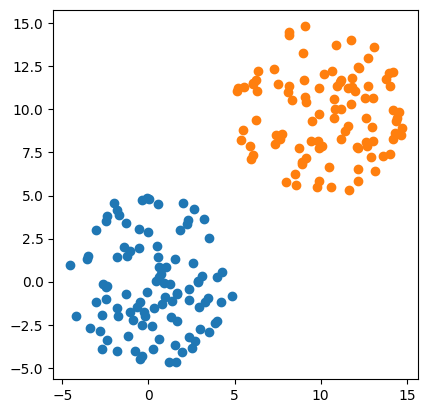

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
def nuage(n,x0,y0,d):
  points=[]
  while len(points) < n:
    x=random.uniform(x0-d,x0+d)
    y=random.uniform(y0-d,y0+d)
    if (x-x0)**2+(y-y0)**2 <=d**2: #(x−x0​)2+(y−y0​)2≤d2 ( au carré)
        points.append((x,y))

  return points

pnt=nuage(100,0,0,5)
print(pnt)
x=[p[0]for p in pnt]
y=[p[1]for p in pnt]
pnt2 = nuage(100, 10, 10, 5)
x2 = [p[0] for p in pnt2]
y2 = [p[1] for p in pnt2]

plt.gca().set_aspect("equal")
plt.scatter(x,y)
plt.scatter(x2,y2)









(b) Afficher ensuite ces 2 nuages de points sur une figure. On utilisera
    ici la fonction `plot` du package `matplotlib.pyplot`. On pourra
    régler l'échelle des axes à l'aide des fonctions `xlim` et `ylim` de
    ce package. Le résultat doit ressembler à la figure suivante:


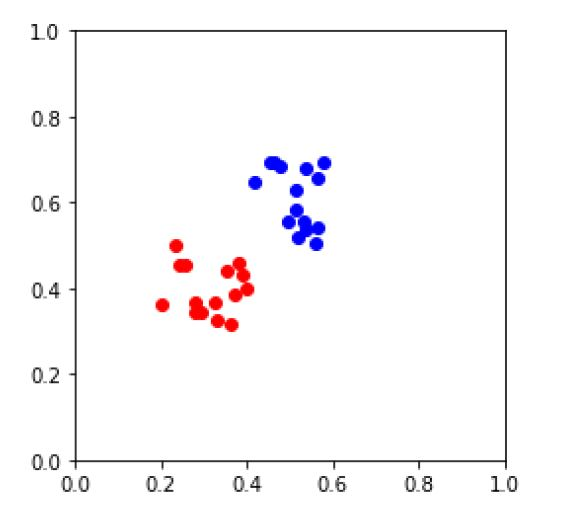

[(0.30753002846761146, 0.2340358932289494), (0.3175105421999037, 0.1725704178991905), (0.23756703246033373, 0.3414880715308096), (0.19505007163901206, 0.13390808872042037), (0.23242867276128054, 0.17550912002920518), (0.17226651042253063, 0.21172253218981912), (0.1558719278060832, 0.18542500011027785), (0.06245020847105416, 0.21932395792468654), (0.144872011874669, 0.3172563258228984), (0.07209225430664823, 0.16830184469478687), (0.31810976406927505, 0.2907820213637785), (0.2955829020446295, 0.17734918037190875), (0.051960005403945395, 0.2135775590153162), (0.2670057367835175, 0.3135000372958855), (0.07673155048014074, 0.19189392363164812)]


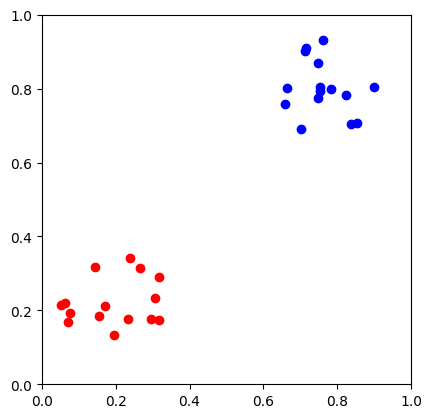

In [ ]:
pnt=nuage(15, 0.2, 0.2, 0.15)
print(pnt)
x=[p[0]for p in pnt]
y=[p[1]for p in pnt]
pnt2 = nuage(15, 0.8, 0.8, 0.15)
x2 = [p[0] for p in pnt2]
y2 = [p[1] for p in pnt2]
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal")
plt.scatter(x,y,color='red',)
plt.scatter(x2,y2, color='blue')

## Classification linéaire à partir des barycentres des classes

(a) Créer une fonction qui à partir d'un nuage de points, déterminera le
    centre du nuage de points.

In [ ]:
from statistics import mean
def centre_nuage(nuage):
  x=[p[0]for p in nuage]
  y=[p[1] for p in nuage]
  x0=mean(x)
  y0=mean(y)
  return(x0,y0)
print(centre_nuage(pnt))
print(centre_nuage(pnt2))

(0.19380194794604233, 0.2231095982553054)
(0.7605358875422352, 0.8023594595229814)


(b) Créer une fonction qui calcule le séparateur de deux groupes de
    points (la médiatrice). La fonction renverra par exemple les
    coordonnées du point milieu M du segment qui relie les centres des
    deux groupes et les coordonnées du vecteur normal à la médiatrice.

 l’équation de la médiatrice :

 Soient deux points A(x1,y1)A(x1​,y1​) et B(x2,y2)B(x2​,y2​).

 a) Trouver le milieu MM : M[(x1+x2)/2,(y1+y2)/2]
 b) Trouver la pente du segment [AB][AB]
p=y2−y1/x2−x1(si x2≠x1)
c) Pente de la médiatrice
La médiatrice est perpendiculaire à [AB], donc sa pente est :

p′=−1/p(si p≠0)

Si p=0 (segment horizontal) → la médiatrice est verticale.
Si x2=x1x2​=x1​ (segment vertical) → la médiatrice est horizontale.

d) Équation de la médiatrice
Avec le point M(xm,ym)et la pente p′ : y−ym​=p′(x−xm​)
ou sous forme développée : y=p′(x−xm​)+ym




Centre nuage bleu: 0.19380194794604233 0.2231095982553054
Centre nuage rouge: 0.7605358875422352 0.8023594595229814
Milieu M: 0.4771689177441388 0.5127345288891434


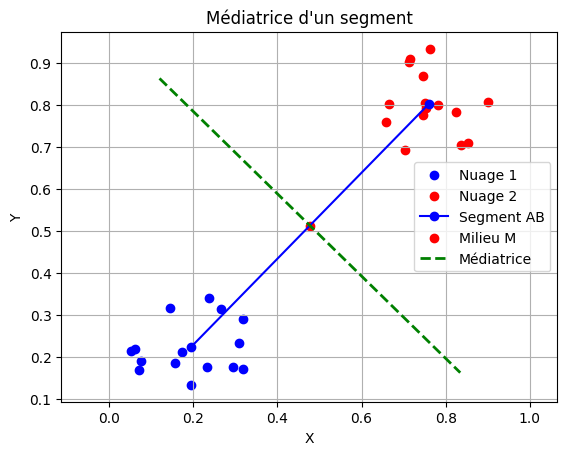

In [ ]:

import matplotlib.pyplot as plt

def tracer_mediatrice(pp, p2):
    x1, y1 = centre_nuage(pp)
    x2, y2 = centre_nuage(p2)

    # Milieu du segment
    xm, ym = (x1 + x2) / 2, (y1 + y2) / 2


  # Points des nuages
    pp_x = [p[0] for p in pp]
    pp_y = [p[1] for p in pp]
    p2_x = [p[0] for p in p2]
    p2_y = [p[1] for p in p2]

    plt.scatter(pp_x, pp_y, color='blue', label='Nuage 1')
    plt.scatter(p2_x, p2_y, color='red', label='Nuage 2')
    # Tracé du segment [AB]
    plt.plot([x1, x2], [y1, y2], 'bo-', label='Segment AB')

    # Tracé du milieu M
    plt.scatter([xm], [ym], color='red', label='Milieu M')
    print("Centre nuage bleu:", x1, y1)
    print("Centre nuage rouge:", x2, y2)
    print("Milieu M:", xm, ym)

   # --- Médiatrice centrée sur M ---
# Longueur souhaitée de la médiatrice autour de M
    l = 0.5  # par exemple 2 fois la distance entre les centres

    if x2 != x1:
      p_seg = (y2 - y1) / (x2 - x1)
      if p_seg != 0:
        p_perp = -1 / p_seg
        # Génération des points pour la médiatrice centrée sur M
        dx = l / (1 + p_perp**2)**0.5
        x_vals = [xm - dx, xm + dx]
        y_vals = [ym - p_perp*dx, ym + p_perp*dx]
      else:  # segment horizontal → médiatrice verticale
        x_vals = [xm, xm]
        y_vals = [ym - l, ym + l]
    else:  # segment vertical → médiatrice horizontale
       x_vals = [xm - l, xm + l]
       y_vals = [ym, ym]
   # Tracé de la médiatrice
    plt.plot(x_vals, y_vals, 'g--', label='Médiatrice', linewidth=2)

    # Mise en forme
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Médiatrice d\'un segment')
    plt.legend()
    plt.grid()
    plt.axis('equal')
    plt.show()

# Exemple d'utilisation

tracer_mediatrice(pnt,pnt2)


(c) Créer ensuite une fonction de décision qui à partir des coordonnées
    d'un point P détermine dans quel groupe de points le séparateur
    précédent classe ce point P. On pourra par exemple utiliser la
    valeur de l'angle entre le vecteur normal à la médiatrice et le
    vecteur $\overrightarrow{MP}$.


In [ ]:
#classer un point 𝑃(𝑥,𝑦) dans l’un des deux nuages de points, en utilisant la médiatrice entre les deux barycentres comme séparateur linéaire.
def decision(point, nuage1, nuage2):
    # Centres des nuages
    x1, y1 = centre_nuage(nuage1)
    x2, y2 = centre_nuage(nuage2)

    # Milieu M du segment entre les centres
    xm, ym = (x1 + x2)/2, (y1 + y2)/2

    # Vecteur normal à la médiatrice
    dx = x2 - x1
    dy = y2 - y1
    if dx != 0 or dy != 0:
        # vecteur normal perpendiculaire à (dx, dy)
        n = (-dy, dx)
    else:
        n = (1, 0)  # au cas improbable où les centres sont identiques

    # Vecteur MP
    mp = (point[0] - xm, point[1] - ym)

    # Produit scalaire
    produit = n[0]*mp[0] + n[1]*mp[1]

    # Décision
    if produit > 0:
        return "Nuage 1"
    else:
        return "Nuage 2"

# --- Exemple d'utilisation ---
p_test = (5, 5)
classe = decision(p_test, pnt, pnt2)
print(f"Le point {p_test} appartient à : {classe}")


Le point (5, 5) appartient à : Nuage 2


(d) Faire afficher sur la figure précédente, les nuages de points, les
    barycentres, le segment qui relie les centres ainsi que la
    médiatrice.

Centre nuage bleu: 0.19380194794604233 0.2231095982553054
Centre nuage rouge: 0.7605358875422352 0.8023594595229814
Milieu M: 0.4771689177441388 0.5127345288891434


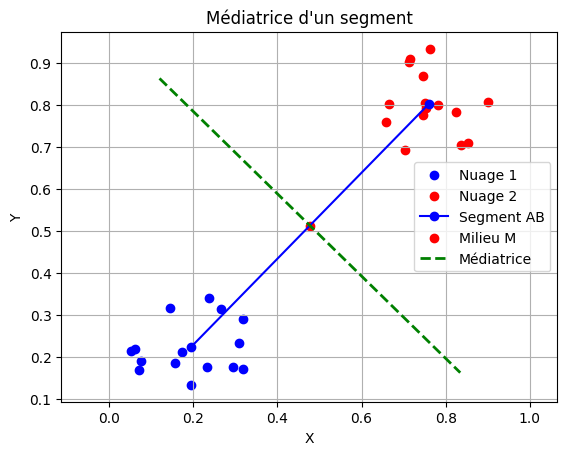

In [ ]:
tracer_mediatrice(pnt, pnt2)

(e) Généraliser ensuite la fonction de décision précédente au cas où le
    nombre de classes est supérieur à 2.

In [ ]:
import math

def decision_multiclasse(point, nuages):
    """
    Détermine à quel nuage appartient un point parmi plusieurs classes.

    point : tuple (x, y)
    nuages : liste contenant les nuages, ex : [nuage1, nuage2, nuage3, ...]

    Retourne l'indice du nuage le plus proche.
    """
    distances = []

    # Calculer la distance entre P et le centre de chaque nuage
    for nuage in nuages:
        cx, cy = centre_nuage(nuage)
        dist = math.sqrt((point[0] - cx)**2 + (point[1] - cy)**2)
        distances.append(dist)

    # Trouver la classe avec la distance minimale
    index_min = distances.index(min(distances))
    return index_min  # renvoie l'indice du nuage


pnt1 = nuage(100, 0, 0, 5)
pnt2 = nuage(100, 10, 10, 5)
pnt3 = nuage(100, -8, 10, 5)

# Regrouper les nuages
nuages = [pnt1, pnt2, pnt3]

# Point test
p_test = (4, 6)

# Décision
classe = decision_multiclasse(p_test, nuages)
print(f"Le point {p_test} appartient à la classe : {classe + 1}")

Le point (4, 6) appartient à la classe : 1


## Classification par la méthode des $k$ plus proches voisins

(a) Charger dans une `DataFrame` la base de données `IRIS` à partir du
    fichier `IRIS.csv`.

    Les colonnes de la DataFrame seront nommées
    `’sl’,’sw’,’pl’,’pw’,’class’`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
iris=pd.read_csv("/content/drive/MyDrive/AA/IRIS.csv",header=None)
iris
iris.columns = ['sl', 'sw', 'pl', 'pw', 'class']

# Afficher les 5 premières lignes
print(iris.head())

    sl   sw   pl   pw        class
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa


(b) Les valeurs de classes
    `’Iris-setosa’,’Iris-versicolor’,’Iris-virginica` seront remplacées
    par des valeurs numériques.

In [ ]:
# Remplacer les classes par des valeurs numériques
classe_num = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}
iris['class'] = iris['class'].map(classe_num)

# Afficher les 5 premières lignes pour vérifier
print(iris.head())

    sl   sw   pl   pw  class
0  5.1  3.5  1.4  0.2      0
1  4.9  3.0  1.4  0.2      0
2  4.7  3.2  1.3  0.2      0
3  4.6  3.1  1.5  0.2      0
4  5.0  3.6  1.4  0.2      0


(c) Créer une fonction `split` qui scindera une DataFrame en deux
    DataFrames dont l'un contiendra 80% des échantillons et l'autre 20%.
    Le premier constituera la base d'apprentissage et le second la base
    de validation (test).

In [ ]:
import pandas as pd
import numpy as np

def split(df, train_ratio=0.8, random_state=None):
    """
    Scinde une DataFrame en deux parties : apprentissage et test.

    Parameters:
        df : pd.DataFrame
            La DataFrame à scinder.
        train_ratio : float
            Proportion des échantillons pour l'apprentissage (défaut 0.8).
        random_state : int
            Graine pour reproduire le tirage aléatoire.

    Returns:
        df_train, df_test : pd.DataFrame
            Les DataFrames d'apprentissage et de test.
    """
    if random_state is not None:
        np.random.seed(random_state)

    # Mélanger les indices
    shuffled_indices = np.random.permutation(df.index)
    n_train = int(len(df) * train_ratio)

    train_indices = shuffled_indices[:n_train]
    test_indices = shuffled_indices[n_train:]

    df_train = df.loc[train_indices].reset_index(drop=True)
    df_test = df.loc[test_indices].reset_index(drop=True)

    return df_train, df_test

# Exemple d'utilisation
df_train, df_test = split(iris, train_ratio=0.8, random_state=42)

print("Taille train :", df_train.shape)
print("Taille test  :", df_test.shape)


Taille train : (120, 5)
Taille test  : (30, 5)


(d) Utiliser la fonction de mélange de la DataFrame créée lors du TP
    précédent pour mélanger les lignes de vos deux DataFrames.

In [ ]:
# A vous...

In [ ]:
import pandas as pd

# Fonction de mélange des lignes
def Melange(df):
    return df.sample(frac=1).reset_index(drop=True)

# Exemple : Mélanger les deux DataFrames créés précédemment
df_train_mel = Melange(df_train)
df_test_mel = Melange(df_test)

# Vérification des résultats
print("Colonnes :", list(df_train_mel.columns))
print("\nPremières lignes du train mélangé :")
print(df_train_mel.head())

print("\nPremières lignes du test mélangé :")
print(df_test_mel.head())

Colonnes : ['sl', 'sw', 'pl', 'pw', 'class']

Premières lignes du train mélangé :
    sl   sw   pl   pw  class
0  4.9  3.1  1.5  0.1      0
1  6.9  3.1  5.4  2.1      2
2  4.4  2.9  1.4  0.2      0
3  7.9  3.8  6.4  2.0      2
4  5.8  2.7  3.9  1.2      1

Premières lignes du test mélangé :
    sl   sw   pl   pw  class
0  5.7  2.8  4.1  1.3      1
1  6.7  3.3  5.7  2.5      2
2  5.9  3.0  5.1  1.8      2
3  7.3  2.9  6.3  1.8      2
4  4.9  2.5  4.5  1.7      2


(e) Créer une fonction qui, à partir d'un point $P$ donné, calcule la
    liste des distances Euclidiennes de $P$ à tous les autres points de
    la base d'apprentissage.

In [ ]:
import numpy as np
import pandas as pd

def distances_euclidiennes(P, df_train):
    """
    Calcule la distance euclidienne entre un point P et tous les points de la base d'apprentissage.

    Paramètres :
        P : array-like ou list
            Le point dont on veut calculer la distance.
        df_train : pd.DataFrame
            La base d'apprentissage (les 4 premières colonnes = caractéristiques).

    Retourne :
        distances : list
            Liste des distances entre P et chaque point du df_train.
    """
    # On suppose que les colonnes de df_train = ['sl','sw','pl','pw','class']
    X_train = df_train.iloc[:, :-1].values  # On enlève la colonne "class"
    P = np.array(P)

    # Calcul des distances euclidiennes
    distances = np.sqrt(np.sum((X_train - P) ** 2, axis=1))
    return distances.tolist()

# Exemple d'utilisation :
P = [5.1, 3.5, 1.4, 0.2]  # Exemple de point Iris
distances = distances_euclidiennes(P, df_train)
print("Premières distances :", distances[:10])

Premières distances : [3.6578682316343767, 0.7416198487095667, 6.498461356351979, 3.531288716601915, 4.047221268969612, 0.3872983346207423, 2.5806975801127883, 4.636809247747852, 3.7682887362833544, 2.8948229652260253]


(f) Créer une fonction qui à partir d'un point $P$ donné et un entier
    $k$ renverra les $k$ plus proches voisins de $P$ au sens de la
    distance Euclidienne calculée précédemment.

In [ ]:
import numpy as np
import pandas as pd

def k_plus_proches_voisins(P, df_train, k):
    """
    Renvoie les k plus proches voisins d'un point P dans la base d'apprentissage.

    Paramètres :
        P : list ou array
            Le point dont on veut trouver les k plus proches voisins.
        df_train : pd.DataFrame
            La base d'apprentissage (dernière colonne = 'class').
        k : int
            Le nombre de voisins les plus proches à retourner.

    Retourne :
        voisins : pd.DataFrame
            Les k plus proches voisins avec leurs distances.
    """
    # Extraction des caractéristiques (sans la colonne 'class')
    X_train = df_train.iloc[:, :-1].values
    P = np.array(P)

    # Calcul des distances euclidiennes
    distances = np.sqrt(np.sum((X_train - P) ** 2, axis=1))

    # Création d'une DataFrame temporaire avec les distances et les classes
    df_distances = df_train.copy()
    df_distances['distance'] = distances

    # Trier par distance croissante et prendre les k premiers
    voisins = df_distances.sort_values(by='distance').head(k).reset_index(drop=True)

    return voisins

# Exemple d'utilisation :
P = [5.1, 3.5, 1.4, 0.2]  # Exemple d'un point Iris
k = 5
voisins = k_plus_proches_voisins(P, df_train, k)

print("Les k plus proches voisins :")
print(voisins)


Les k plus proches voisins :
    sl   sw   pl   pw  class  distance
0  5.1  3.5  1.4  0.2      0  0.000000
1  5.1  3.5  1.4  0.3      0  0.100000
2  5.0  3.6  1.4  0.2      0  0.141421
3  5.1  3.4  1.5  0.2      0  0.141421
4  5.2  3.5  1.5  0.2      0  0.141421


(g) Créer ensuite une fonction de décision qui, à partir d'un point $P$
    donné et du nombre de voisins $k$, renverra la classe majoritaire
    parmi les $k$ voisins de $P$ considérée comme la classe de $P$.

In [ ]:
import numpy as np
import pandas as pd

def decision_knn(P, df_train, k):
    """
    Prédit la classe d'un point P en utilisant la méthode des k plus proches voisins.

    Paramètres :
        P : list ou array
            Le point dont on veut prédire la classe.
        df_train : pd.DataFrame
            La base d'apprentissage (dernière colonne = 'class').
        k : int
            Le nombre de voisins à considérer.

    Retourne :
        classe_predite : int
            La classe prédite pour le point P.
    """
    # Récupération des k plus proches voisins
    voisins = k_plus_proches_voisins(P, df_train, k)

    # Récupérer les classes des voisins
    classes_voisins = voisins['class'].values

    # Trouver la classe majoritaire
    valeurs, nb_occurrences = np.unique(classes_voisins, return_counts=True)
    indice_max = np.argmax(nb_occurrences)
    classe_predite = valeurs[indice_max]

    return classe_predite

# Exemple d'utilisation :
P = [5.1, 3.5, 1.4, 0.2]  # Exemple d'un point Iris
k = 5
classe = decision_knn(P, df_train, k)

print(f"La classe prédite pour le point {P} est : {classe}")


La classe prédite pour le point [5.1, 3.5, 1.4, 0.2] est : 0


(h) En utilisant la fonction de décision créée précédemment, créer
    maintenant une fonction qui calculera l'erreur de prédiction sur la
    base de test (le deuxième DataFrame).

In [ ]:
def erreur_prediction(df_test, df_train, k):
    """
    Calcule le taux d'erreur de prédiction sur la base de test.

    Paramètres :
        df_test : pd.DataFrame
            La base de test.
        df_train : pd.DataFrame
            La base d'apprentissage.
        k : int
            Le nombre de voisins à considérer.

    Retourne :
        erreur : float
            Le taux d'erreur (entre 0 et 1).
    """
    erreurs = 0

    for i in range(len(df_test)):
        # Extraire le point sans la classe
        P = df_test.iloc[i, :-1].values

        # Classe réelle
        classe_reelle = df_test.iloc[i, -1]

        # Classe prédite par notre modèle k-NN
        classe_predite = decision_knn(P, df_train, k)

        # Vérification de la prédiction
        if classe_predite != classe_reelle:
            erreurs += 1

    # Calcul du taux d'erreur
    erreur = erreurs / len(df_test)
    return erreur

# Exemple d'utilisation :
k = 5
erreur = erreur_prediction(df_test, df_train, k)
print(f"Taux d'erreur pour k={k} : {erreur:.2f}")


Taux d'erreur pour k=5 : 0.03


 (i) Etudier l'évolution de l'erreur de prédiction sur la base de test en
    fonction du choix de $k$.


k=1 → Erreur=0.033
k=2 → Erreur=0.033
k=3 → Erreur=0.033
k=4 → Erreur=0.033
k=5 → Erreur=0.033
k=6 → Erreur=0.033
k=7 → Erreur=0.033
k=8 → Erreur=0.033
k=9 → Erreur=0.033
k=10 → Erreur=0.033
k=11 → Erreur=0.033
k=12 → Erreur=0.033
k=13 → Erreur=0.033
k=14 → Erreur=0.033
k=15 → Erreur=0.033
k=16 → Erreur=0.033
k=17 → Erreur=0.033
k=18 → Erreur=0.033
k=19 → Erreur=0.033
k=20 → Erreur=0.033


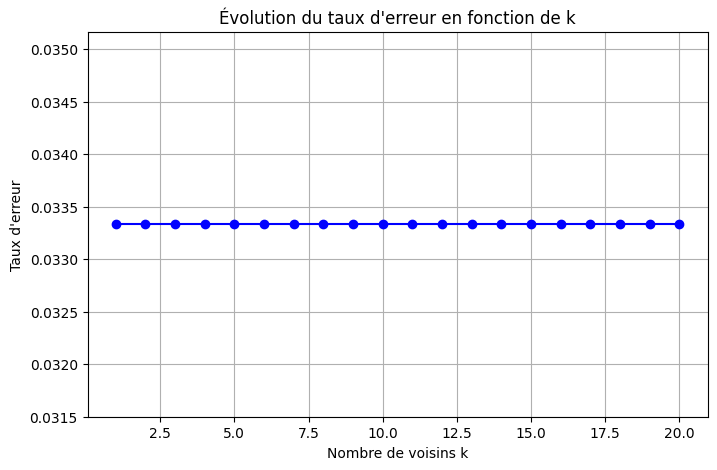

In [ ]:
import matplotlib.pyplot as plt

def evolution_erreur(df_train, df_test, k_max=20):
    """
    Étudie l'évolution de l'erreur de prédiction en fonction de k.

    Paramètres :
        df_train : pd.DataFrame
            La base d'apprentissage.
        df_test : pd.DataFrame
            La base de test.
        k_max : int
            Le nombre maximal de voisins à tester.

    Retourne :
        k_values : list
            Liste des valeurs de k testées.
        erreurs : list
            Liste des taux d'erreurs correspondants.
    """
    k_values = list(range(1, k_max + 1))
    erreurs = []

    for k in k_values:
        err = erreur_prediction(df_test, df_train, k)
        erreurs.append(err)
        print(f"k={k} → Erreur={err:.3f}")

    # Tracer la courbe d'évolution
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, erreurs, marker='o', linestyle='-', color='b')
    plt.xlabel("Nombre de voisins k")
    plt.ylabel("Taux d'erreur")
    plt.title("Évolution du taux d'erreur en fonction de k")
    plt.grid()
    plt.show()

    return k_values, erreurs

# Exemple d'utilisation :
k_values, erreurs = evolution_erreur(df_train, df_test, k_max=20)


(j) Etudier l'évolution de l'erreur de prédiction sur la base de test en
    fonction du nombre de points utilisés pour l'apprentissage et pour
    le test.

Proportion d'apprentissage=0.20 → Erreur=0.092
Proportion d'apprentissage=0.40 → Erreur=0.033
Proportion d'apprentissage=0.60 → Erreur=0.050
Proportion d'apprentissage=0.80 → Erreur=0.033


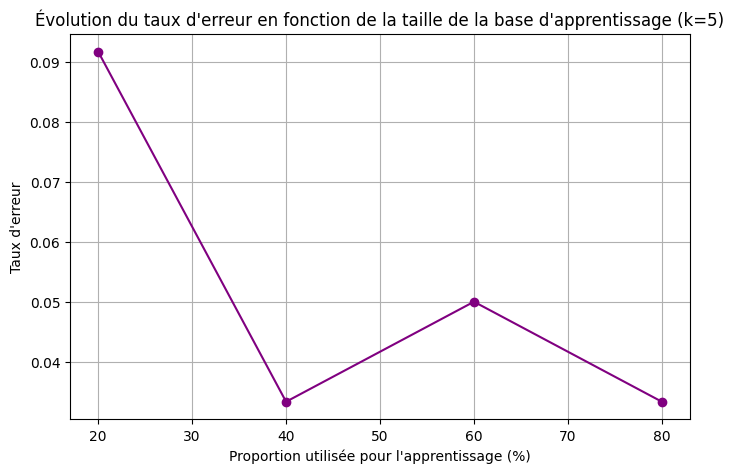

In [ ]:
import matplotlib.pyplot as plt

def evolution_erreur_apprentissage(iris, k=5, proportions=None):
    """
    Étudie l'évolution de l'erreur de prédiction en fonction de la taille
    de la base d'apprentissage et de la base de test.

    Paramètres :
        iris : pd.DataFrame
            La base complète.
        k : int
            Nombre de voisins pour k-NN.
        proportions : list
            Liste des proportions de données utilisées pour l'apprentissage.

    Retourne :
        proportions : list
            Proportions utilisées.
        erreurs : list
            Liste des taux d'erreurs correspondants.
    """
    if proportions is None:
        proportions = [0.2, 0.4, 0.6, 0.8]  # Par défaut

    erreurs = []

    for p in proportions:
        # Découper la base selon la proportion
        df_train, df_test = split(iris, train_ratio=p, random_state=42)

        # Calcul de l'erreur pour ce split
        err = erreur_prediction(df_test, df_train, k)
        erreurs.append(err)

        print(f"Proportion d'apprentissage={p:.2f} → Erreur={err:.3f}")

    # Tracé du graphique
    plt.figure(figsize=(8, 5))
    plt.plot([int(p*100) for p in proportions], erreurs, marker='o', color='purple')
    plt.xlabel("Proportion utilisée pour l'apprentissage (%)")
    plt.ylabel("Taux d'erreur")
    plt.title(f"Évolution du taux d'erreur en fonction de la taille de la base d'apprentissage (k={k})")
    plt.grid()
    plt.show()

    return proportions, erreurs

# Exemple d'utilisation :
proportions, erreurs = evolution_erreur_apprentissage(iris, k=5)


(k) Créer des variantes de cet algorithme en remplaçant la distance
    Euclidienne par d'autres choix de distances.

In [ ]:
import numpy as np
import pandas as pd

def distance(P, Q, type_distance="euclidienne", p=3):
    """
    Calcule la distance entre deux points selon le type choisi.

    Paramètres :
        P, Q : array-like
        type_distance : str, "euclidienne", "manhattan", "minkowski", "chebyshev"
        p : int, utilisé pour Minkowski
    """
    P = np.array(P)
    Q = np.array(Q)

    if type_distance == "euclidienne":
        return np.sqrt(np.sum((P - Q) ** 2))
    elif type_distance == "manhattan":
        return np.sum(np.abs(P - Q))
    elif type_distance == "minkowski":
        return np.sum(np.abs(P - Q) ** p) ** (1/p)
    elif type_distance == "chebyshev":
        return np.max(np.abs(P - Q))
    else:
        raise ValueError("Type de distance non reconnu")

def k_plus_proches_voisins_distance(P, df_train, k, type_distance="euclidienne", p=3):
    """
    Renvoie les k plus proches voisins selon le type de distance choisi.
    """
    X_train = df_train.iloc[:, :-1].values
    P = np.array(P)

    # Calcul des distances selon le type choisi
    distances = np.array([distance(P, X_train[i], type_distance, p) for i in range(len(X_train))])

    df_distances = df_train.copy()
    df_distances['distance'] = distances

    voisins = df_distances.sort_values(by='distance').head(k).reset_index(drop=True)
    return voisins

def decision_knn_distance(P, df_train, k, type_distance="euclidienne", p=3):
    """
    Prédit la classe d'un point selon k-NN et le type de distance choisi.
    """
    voisins = k_plus_proches_voisins_distance(P, df_train, k, type_distance, p)
    classes_voisins = voisins['class'].values
    valeurs, nb_occurrences = np.unique(classes_voisins, return_counts=True)
    return valeurs[np.argmax(nb_occurrences)]

# Exemple d'utilisation :
P = [5.1, 3.5, 1.4, 0.2]
k = 5
classe_pred = decision_knn_distance(P, df_train, k, type_distance="manhattan")
print(f"Classe prédite avec distance Manhattan : {classe_pred}")

